<a href="https://colab.research.google.com/github/dhivyaskarunya-coder/Namma-Yatri-1/blob/main/Namma_yatri1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Load your dataset (update file path)
df = pd.read_csv("/content/Namma_yatri_data.csv")

# Remove commas, currency symbols, spaces
df["Drivers' Earnings"] = df["Drivers' Earnings"].replace('[₹,]', '', regex=True)

# Convert to numeric
df["Drivers' Earnings"] = pd.to_numeric(df["Drivers' Earnings"], errors='coerce')

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Preview:")
print(df.head())

Saving Namma_yatri_data.csv to Namma_yatri_data (1).csv
Dataset Preview:
        City      Searches Searches which got estimate Searches for Quotes  \
0  Bangalore  13,36,78,174                11,98,99,866        10,43,92,222   
1    Kolkata   1,64,33,036                 1,59,55,942         1,00,80,497   
2      Kochi     19,09,082                   18,11,065           11,46,766   
3    Chennai     27,77,020                   27,35,741           12,62,282   
4     Mysore      5,09,102                    4,98,886            2,94,152   

  Searches which got Quotes     Bookings Completed Trips  \
0               5,80,76,082  5,72,20,933     3,63,80,329   
1                 62,00,694    50,49,073       29,85,299   
2                  8,34,920     7,57,908        5,16,972   
3                  6,90,006     6,87,618        3,68,974   
4                  2,67,197     2,62,530        1,74,103   

  Search-to-estimate Rate Rider Fare Acceptance  Rate  \
0                  89.70%               

In [ ]:
df.columns = df.columns.str.strip()


In [ ]:
def clean_numeric_column(col):
    return (
        col.astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('₹', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.strip()
    )

for col in df.columns:
    if col != "City":
        df[col] = clean_numeric_column(df[col])
        df[col] = pd.to_numeric(df[col], errors='coerce')

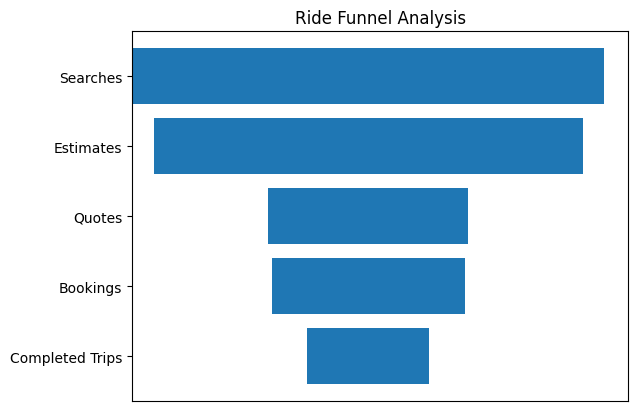

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Funnel data
funnel = {
    "Searches": df["Searches"].sum(),
    "Estimates": df["Searches which got estimate"].sum(),
    "Quotes": df["Searches which got Quotes"].sum(),
    "Bookings": df["Bookings"].sum(),
    "Completed Trips": df["Completed Trips"].sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=["Stage", "Count"])

# Sort descending (important)
funnel_df = funnel_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

# Normalize widths for symmetry
max_value = funnel_df["Count"].max()
widths = funnel_df["Count"] / max_value

y = np.arange(len(funnel_df))

plt.figure()

# Draw centered bars (left = -width/2, width = width)
plt.barh(y, widths, left=-widths/2)

# Labels
plt.yticks(y, funnel_df["Stage"])
plt.gca().invert_yaxis()

plt.title("Ride Funnel Analysis")

# Remove x-axis (for clean funnel look)
plt.xticks([])
plt.xlabel("")

plt.show()

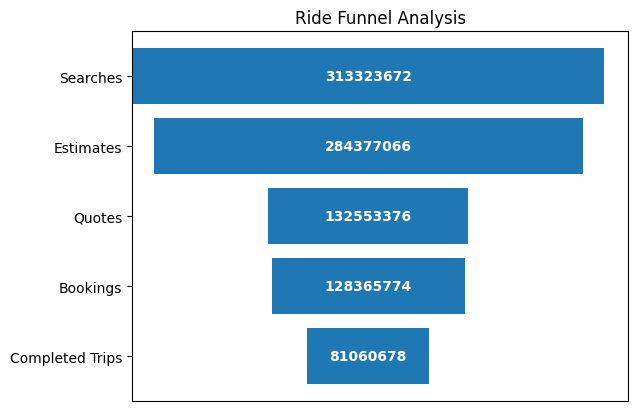

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Funnel data
funnel = {
    "Searches": df["Searches"].sum(),
    "Estimates": df["Searches which got estimate"].sum(),
    "Quotes": df["Searches which got Quotes"].sum(),
    "Bookings": df["Bookings"].sum(),
    "Completed Trips": df["Completed Trips"].sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=["Stage", "Count"])

# Sort descending
funnel_df = funnel_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

# Normalize widths
max_value = funnel_df["Count"].max()
widths = funnel_df["Count"] / max_value

y = np.arange(len(funnel_df))

plt.figure()

# Draw funnel bars
bars = plt.barh(y, widths, left=-widths/2)

# Add numbers inside bars
for i, (w, val) in enumerate(zip(widths, funnel_df["Count"])):
    plt.text(0, i, f"{val}", ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# Labels
plt.yticks(y, funnel_df["Stage"])
plt.gca().invert_yaxis()

plt.title("Ride Funnel Analysis")

# Remove x-axis
plt.xticks([])
plt.xlabel("")

plt.show()

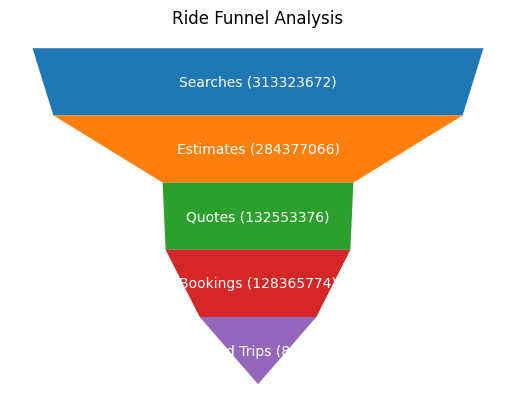

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Funnel data
funnel = {
    "Searches": df["Searches"].sum(),
    "Estimates": df["Searches which got estimate"].sum(),
    "Quotes": df["Searches which got Quotes"].sum(),
    "Bookings": df["Bookings"].sum(),
    "Completed Trips": df["Completed Trips"].sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=["Stage", "Count"])

# Sort descending
funnel_df = funnel_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

# Normalize widths
max_val = funnel_df["Count"].max()
funnel_df["Width"] = funnel_df["Count"] / max_val

plt.figure()

for i in range(len(funnel_df)):
    top_width = funnel_df.loc[i, "Width"]
    bottom_width = funnel_df.loc[i+1, "Width"] if i+1 < len(funnel_df) else 0

    # Define trapezoid shape
    x = [-top_width/2, top_width/2, bottom_width/2, -bottom_width/2]
    y = [i, i, i+1, i+1]

    plt.fill(x, y)

    # Add label
    plt.text(0, i + 0.5,
             f"{funnel_df.loc[i, 'Stage']} ({funnel_df.loc[i, 'Count']})",
             ha='center', va='center', color='white', fontsize=10)

# Formatting
plt.gca().invert_yaxis()
plt.axis('off')
plt.title("Ride Funnel Analysis")

plt.show()

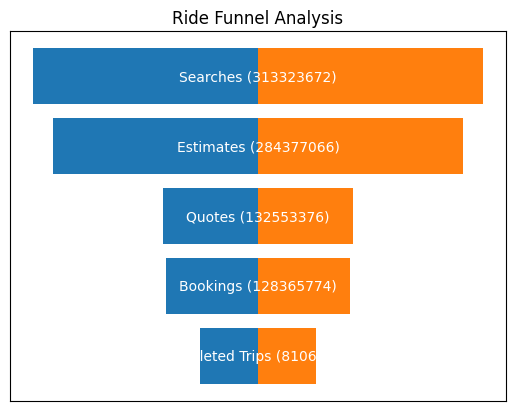

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Funnel data
funnel = {
    "Searches": df["Searches"].sum(),
    "Estimates": df["Searches which got estimate"].sum(),
    "Quotes": df["Searches which got Quotes"].sum(),
    "Bookings": df["Bookings"].sum(),
    "Completed Trips": df["Completed Trips"].sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=["Stage", "Count"])

# Sort descending
funnel_df = funnel_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

# Normalize
max_val = funnel_df["Count"].max()
funnel_df["Norm"] = funnel_df["Count"] / max_val

y = np.arange(len(funnel_df))

plt.figure()

# Left side (negative)
plt.barh(y, -funnel_df["Norm"])

# Right side (positive)
plt.barh(y, funnel_df["Norm"])

# Labels in center
for i in range(len(funnel_df)):
    plt.text(0, i,
             f"{funnel_df.loc[i,'Stage']} ({funnel_df.loc[i,'Count']})",
             ha='center', va='center', color='white')

# Formatting
plt.gca().invert_yaxis()
plt.xticks([])
plt.yticks([])
plt.title("Ride Funnel Analysis")
plt.xlabel("")
plt.ylabel("")

plt.show()

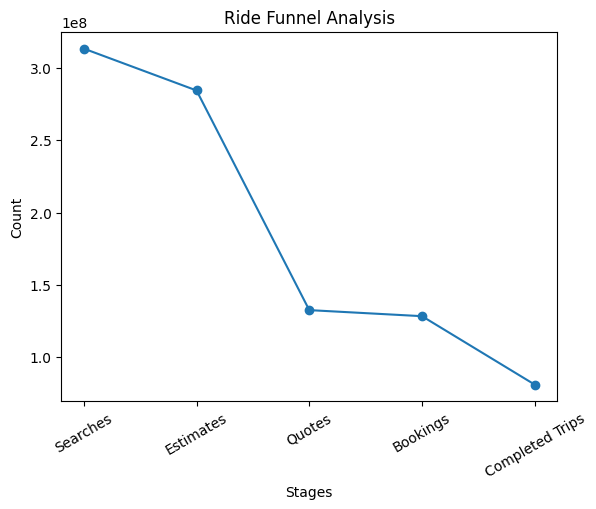

In [ ]:
funnel = {
    "Searches": df["Searches"].sum(),
    "Estimates": df["Searches which got estimate"].sum(),
    "Quotes": df["Searches which got Quotes"].sum(),
    "Bookings": df["Bookings"].sum(),
    "Completed Trips": df["Completed Trips"].sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=["Stage", "Count"])

plt.figure()
plt.plot(funnel_df["Stage"], funnel_df["Count"], marker='o')
plt.title("Ride Funnel Analysis")
plt.xlabel("Stages")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [ ]:
features = [
    "Searches",
    "Searches which got estimate",
    "Searches for Quotes",
    "Searches which got Quotes",
    "Average Fare per Trip",
    "Average Distance per Trip (km)"
]

target = "Conversion Rate"

X = df[features]
y = df[target]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Average Fare per Trip']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Average Fare per Trip']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [ ]:
import numpy as np

print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Fill missing values with mean
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Model Performance:
Mean Squared Error: 32.42581988044691
R2 Score: 0.36572311838335536


In [ ]:
accuracy = r2 * 100
print("Model Accuracy (%):", accuracy)

Model Accuracy (%): 36.57231183833554


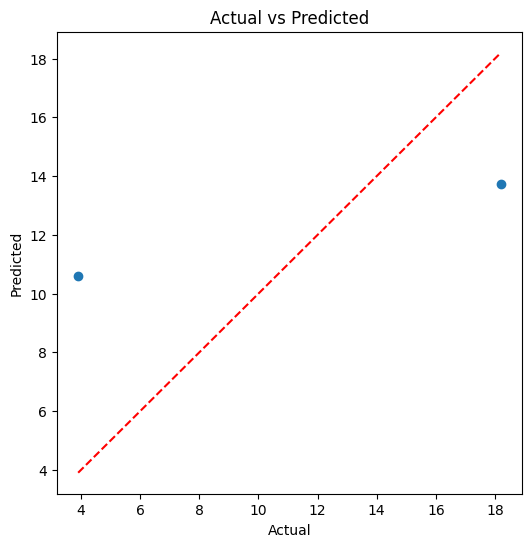

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

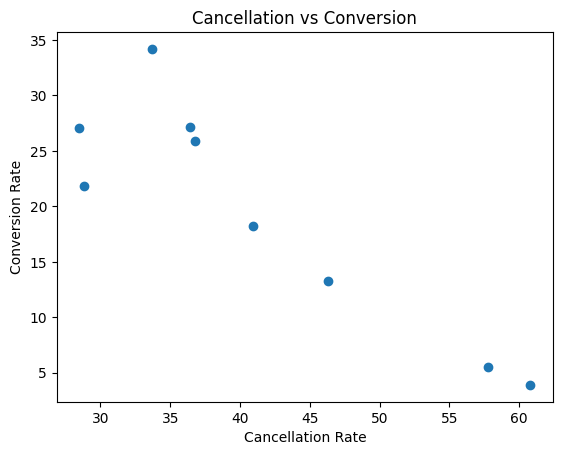

In [ ]:
plt.figure()
plt.scatter(df["Booking Cancellation Rate"], df["Conversion Rate"])
plt.xlabel("Cancellation Rate")
plt.ylabel("Conversion Rate")
plt.title("Cancellation vs Conversion")
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print(df[["Drivers' Earnings"]].head(10))


Saving Namma_yatri_data.csv to Namma_yatri_data (2).csv
  Drivers' Earnings
0  ??5,14,97,58,044
1    ??79,87,56,227
2    ??12,51,73,631
3     ??5,65,05,740
4     ??1,51,38,573
5       ??30,14,316
6       ??74,56,593
7       ??17,00,016
8  ??6,15,75,03,140


In [ ]:
# Remove corrupted symbols and commas
df["Drivers' Earnings"] = df["Drivers' Earnings"].astype(str)
df["Drivers' Earnings"] = df["Drivers' Earnings"].str.replace("??", "", regex=False)
df["Drivers' Earnings"] = df["Drivers' Earnings"].str.replace(",", "", regex=False)
df["Drivers' Earnings"] = df["Drivers' Earnings"].str.strip()

# Convert to numeric
df["Drivers' Earnings"] = pd.to_numeric(df["Drivers' Earnings"], errors='coerce')

# Fill missing values with mean
df["Drivers' Earnings"] = df["Drivers' Earnings"].fillna(
    df["Drivers' Earnings"].mean()
)

# Check result
print(df["Drivers' Earnings"].head(10))

0    5149758044
1     798756227
2     125173631
3      56505740
4      15138573
5       3014316
6       7456593
7       1700016
8    6157503140
Name: Drivers' Earnings, dtype: int64


In [ ]:
# Remove ₹, commas, spaces
df["Drivers' Earnings"] = df["Drivers' Earnings"].astype(str)
df["Drivers' Earnings"] = df["Drivers' Earnings"].str.replace("₹", "", regex=False)
df["Drivers' Earnings"] = df["Drivers' Earnings"].str.replace(",", "", regex=False)
df["Drivers' Earnings"] = df["Drivers' Earnings"].str.strip()

# Convert to numeric
df["Drivers' Earnings"] = pd.to_numeric(df["Drivers' Earnings"], errors='coerce')

In [ ]:
print(df["Drivers' Earnings"].mean())

1368334031.1111112


In [ ]:
# Convert to numeric
df["Drivers' Earnings"] = pd.to_numeric(df["Drivers' Earnings"], errors='coerce')

# Fill missing with mean
df["Drivers' Earnings"].fillna(df["Drivers' Earnings"].mean(), inplace=True)

print(df["Drivers' Earnings"].head())

0    5149758044
1     798756227
2     125173631
3      56505740
4      15138573
Name: Drivers' Earnings, dtype: int64


/tmp/ipykernel_9494/3197315709.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Drivers' Earnings"].fillna(df["Drivers' Earnings"].mean(), inplace=True)


In [ ]:
# Remove % symbols from all percentage columns
for col in df.columns:
    if df[col].dtype == 'object' and col != "City":
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = df[col].str.replace(',', '', regex=False)
        df[col] = df[col].str.replace('??', '', regex=False)
        df[col] = df[col].str.strip()

# Convert all non-city columns to numeric
for col in df.columns:
    if col != "City":
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values with column mean
for col in df.columns:
    if col != "City":
        df[col] = df[col].fillna(df[col].mean())


City Performance:
             Conversion Rate  Booking Cancellation Rate  Drivers' Earnings
City                                                                      
Bangalore               27.2                       36.4       5.149758e+09
Chennai                 13.3                       46.3       5.650574e+07
Delhi                    3.9                       60.8       1.700016e+06
Hyderabad                5.5                       57.8       7.456593e+06
India Total             25.9                       36.8       6.157503e+09
Kochi                   27.1                       28.5       1.251736e+08
Kolkata                 18.2                       40.9       7.987562e+08
Mysore                  34.2                       33.7       1.513857e+07
Tumkuru                 21.8                       28.8       3.014316e+06


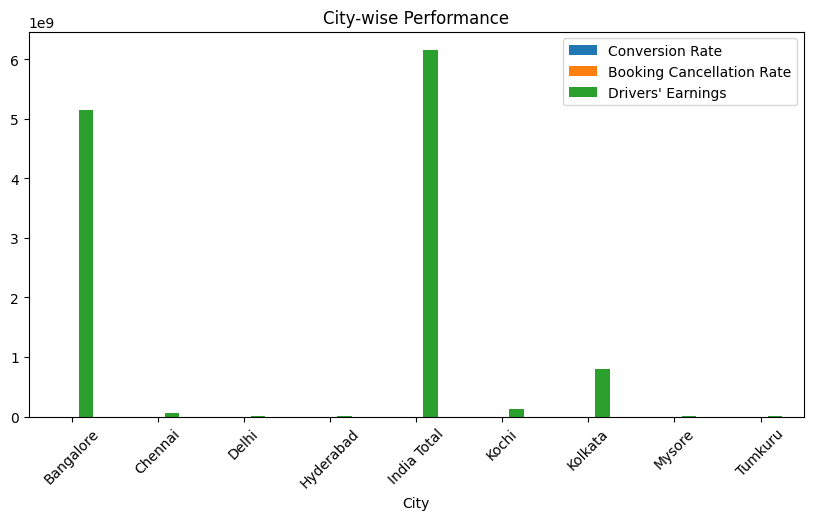

In [ ]:
city_perf = df.groupby("City")[[
    "Conversion Rate",
    "Booking Cancellation Rate",
    "Drivers' Earnings"
]].mean()

print("\nCity Performance:")
print(city_perf)

city_perf.plot(kind="bar", figsize=(10,5))
plt.title("City-wise Performance")
plt.xticks(rotation=45)
plt.show()

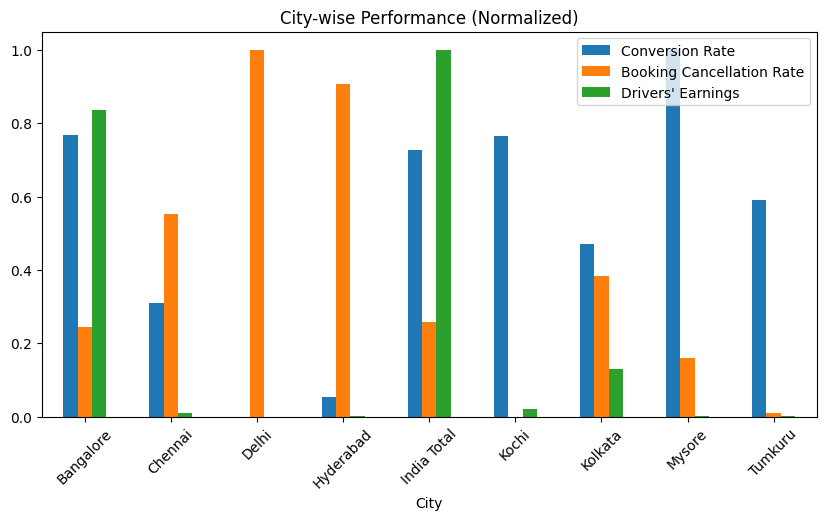

In [ ]:
city_perf_norm = (city_perf - city_perf.min()) / (city_perf.max() - city_perf.min())

city_perf_norm.plot(kind="bar", figsize=(10,5))
plt.title("City-wise Performance (Normalized)")
plt.xticks(rotation=45)
plt.show()

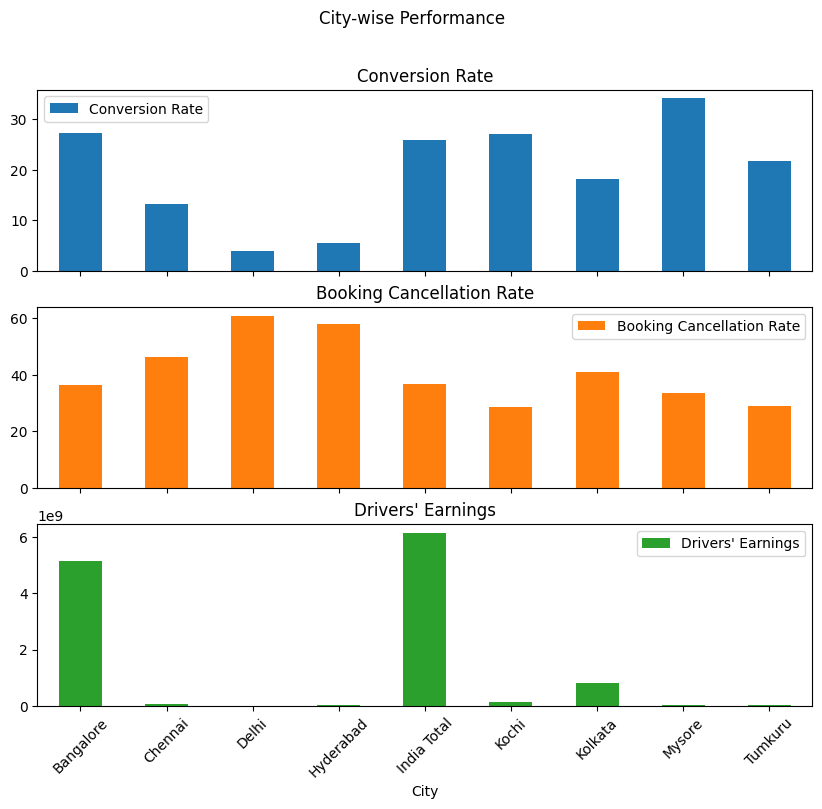

In [ ]:
city_perf.plot(subplots=True, kind="bar", figsize=(10,8))

plt.suptitle("City-wise Performance")
plt.xticks(rotation=45)
plt.show()

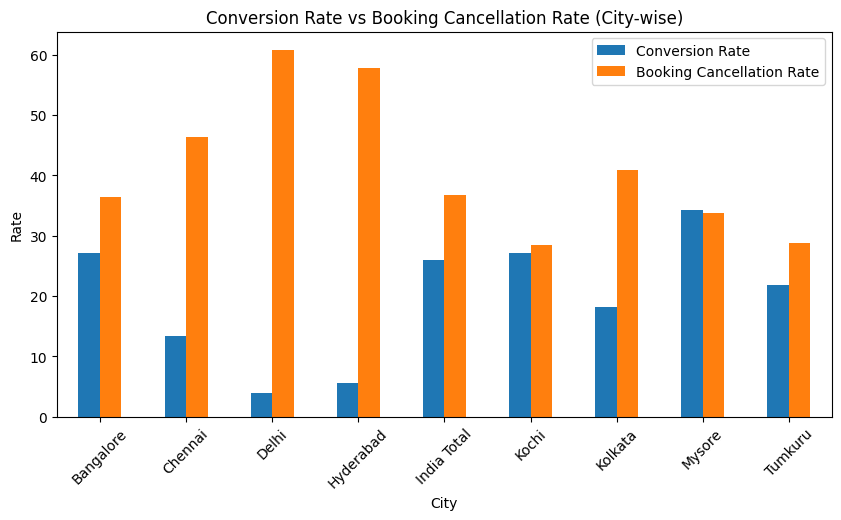

In [ ]:
import matplotlib.pyplot as plt

# Select only required columns
compare = df.groupby("City")[[
    "Conversion Rate",
    "Booking Cancellation Rate"
]].mean()

# Plot
compare.plot(kind="bar", figsize=(10,5))

plt.title("Conversion Rate vs Booking Cancellation Rate (City-wise)")
plt.xlabel("City")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict
y_pred = model.predict(X_test)

# Regression metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score (Accuracy):", r2)
print("Accuracy Percentage:", r2 * 100)
print("RMSE:", rmse)
print("MAE:", mae)

R2 Score (Accuracy): 0.36572311838335536
Accuracy Percentage: 36.57231183833554
RMSE: 5.694367381935145
MAE: 5.58497715420213


In [ ]:
pip install pandas matplotlib seaborn

In [ ]:
import pandas as pd

# Load CSV file
file_path = "Namma_yatri_data.csv"
df = pd.read_csv(file_path)

print(df.head())

        City      Searches Searches which got estimate Searches for Quotes  \
0  Bangalore  13,36,78,174                11,98,99,866        10,43,92,222   
1    Kolkata   1,64,33,036                 1,59,55,942         1,00,80,497   
2      Kochi     19,09,082                   18,11,065           11,46,766   
3    Chennai     27,77,020                   27,35,741           12,62,282   
4     Mysore      5,09,102                    4,98,886            2,94,152   

  Searches which got Quotes     Bookings Completed Trips  \
0               5,80,76,082  5,72,20,933     3,63,80,329   
1                 62,00,694    50,49,073       29,85,299   
2                  8,34,920     7,57,908        5,16,972   
3                  6,90,006     6,87,618        3,68,974   
4                  2,67,197     2,62,530        1,74,103   

  Search-to-estimate Rate Rider Fare Acceptance  Rate  \
0                  89.70%                      87.10%   
1                  97.10%                      63.20%   

In [ ]:
import numpy as np

# Remove commas and convert numeric columns
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = df[col].str.replace('%', '', regex=False)
    df[col] = df[col].str.replace('??', '', regex=False)

# Convert possible numeric columns
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

City                               object
Searches                            int64
Searches which got estimate         int64
Searches for Quotes                 int64
Searches which got Quotes           int64
Bookings                            int64
Completed Trips                     int64
Search-to-estimate Rate           float64
Rider Fare Acceptance  Rate       float64
Driver Quote Acceptance Rate      float64
Quote-to-booking Rate             float64
Cancelled Bookings                  int64
Booking Cancellation Rate         float64
Driver Cancellation Rate          float64
User Cancellation Rate            float64
Conversion Rate                   float64
Drivers' Earnings                   int64
Average Distance per Trip (km)    float64
Average Fare per Trip             float64
Distance Travelled (km)             int64
dtype: object


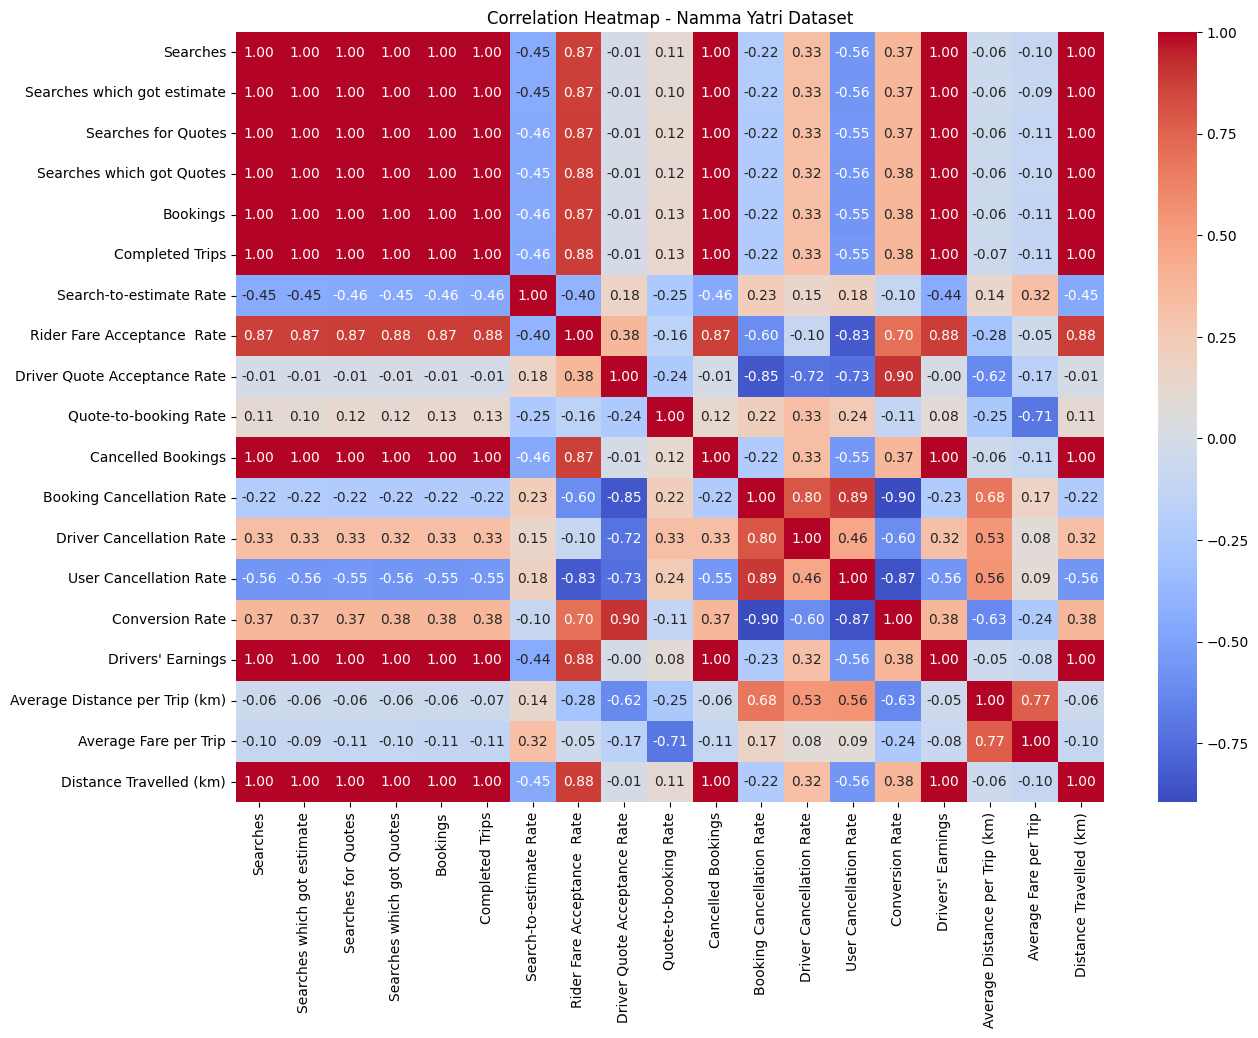

In [ ]:
import seaborn as sns

# Correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap - Namma Yatri Dataset')
plt.show()

In [ ]:
# Select important columns
selected_cols = [
    'Bookings',
    'Completed Trips',
    'Conversion Rate',
    'Booking Cancellation Rate',
    'Average Fare per Trip'
]

heatmap_data = city_df[selected_cols]

# Plot
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu',
    fmt='.1f'
)

plt.title('City-wise Performance Heatmap')
plt.show()

NameError: name 'city_df' is not defined